# Using the new sampler classes

Just a simple notebook here where we use the implemented samplers.

## Linear regression

One of the easiest models we can look at is a simple linear regression with a Gaussian prior on the coefficients.
\begin{align}
\pi(\mathbf{y} \vert \boldsymbol{\beta},X) = \mathcal{N}(X\boldsymbol{\beta},\sigma^2I),  \ \ \ \ \pi(\boldsymbol{\beta})=\mathcal{N}(0,\alpha^2I).
\end{align}

All the sampler need is the gradient of the log-posterior 
\begin{align}
\nabla_{\boldsymbol{\beta}} \ U(\boldsymbol{\beta}) &= \nabla_{\boldsymbol{\beta}} \ \left[\log \mathcal{N}(X\boldsymbol{\beta},\sigma^2I) + \log \mathcal{N}(0,\alpha^2I)\right] \\
&= \nabla_{\boldsymbol{\beta}} \ \left[ C(\sigma^2) -\frac{1}{2}\left(\frac{1}{\sigma^2}(\mathbf{y}-X\boldsymbol{\beta})^T(\mathbf{y}-X\boldsymbol{\beta})\right) - \frac{1}{2}\left(\frac{\boldsymbol{\beta}^T\boldsymbol{\beta}}{\alpha^2}\right) \right],
\end{align}
where $C(\sigma^2)$ is some constant that depend on \sigma^2, which we for now take as fixed.

In [18]:
import numpy as np
# Okay, now onto some actual code
# I need to sample some true coefficients, a design matrix and some actual data
n = 1000
d = 10
alpha = 2.0
sigma = 1.0
X = np.random.randn(n, d)
beta = np.random.normal(0,alpha,size=d)
epsilon = np.random.normal(0,sigma,size=n)
y = X @ beta + epsilon


In [41]:
import jax.numpy as jnp
from jax import grad, jit
from functools import partial

def target(beta,y,X,sigma,alpha):
    yhat = jnp.matmul(X, beta)
    res = y-yhat
    restres = jnp.matmul(jnp.transpose(res),res)
    btb = jnp.matmul(jnp.transpose(beta),beta)
    u = (restres / sigma**2) + (btb / alpha**2)
    return 0.5*u

u = partial(target,y = y, X = X, sigma = sigma, alpha = alpha)
d_target = jit(grad(u,argnums=(0)))


In [43]:
# Now setting up sampler
from sazz.samplers.AutomaticZigZagSampler import AutomaticZigZagSampler

sampler = AutomaticZigZagSampler(N=20000,D=d,grad_target=d_target,gamma=0.001)
sampler.sample()

Zig-Zag time:   0%|          | 0/20000 [00:00<?, ?iter/s]

Time passed: 2739.610850178639


Text(0, 0.5, 'beta_1')

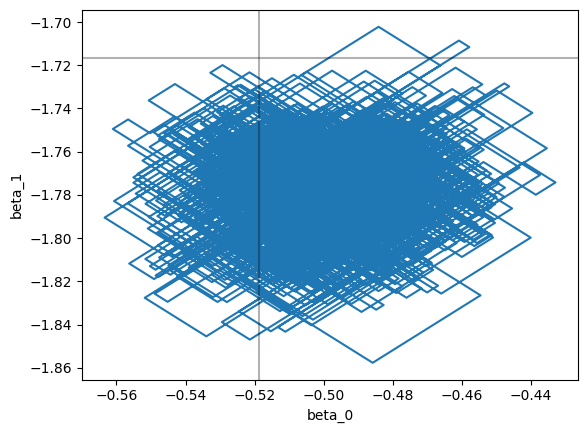

In [49]:
import matplotlib.pyplot as plt
Position = sampler.Position
i1 = 0
i2 = 1
plt.plot(Position[10000:,i1], Position[10000:,i2])
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)
plt.xlabel("beta_"+str(i1))
plt.ylabel("beta_"+str(i2))


In [50]:
points = sampler.getSamples(N_samples = 20000)

In [51]:
points.shape

(20000, 10)

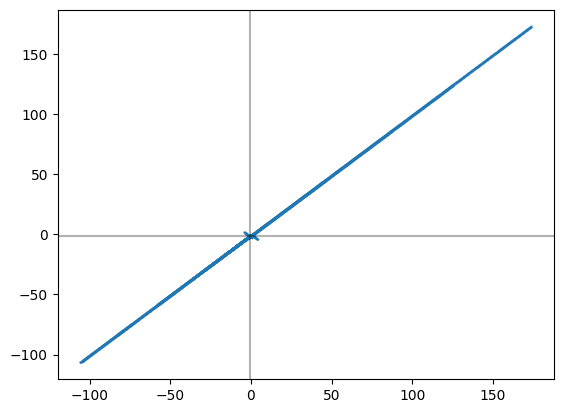

In [53]:
plt.scatter(points[10000:, i1], points[10000:, i2], alpha=0.5, label="Samples",s=0.5)
plt.axvline(beta[i1],color="black",alpha=0.3)
plt.axhline(beta[i2],color="black",alpha=0.3)